# What Drives Inflation?
### A Machine Learning and Time Series Analysis of U.S. CPI Inflation Data*

___ ___

# Objective

Inflation is one of the most consequential macroeconomic variables for households, businesses, and policymakers, yet the relative importance of its drivers (e.g.,labour market tightness, monetary policy, financial conditions, and inflation expectations) remains actively debated. Standard approaches often fail to capture the complexity of modern inflation dynamics, particularly during regime shifts such as the post-COVID surge.  

This analysis addresses two questions:  
What are the primary economic drivers of U.S. CPI inflation, and what is their relative importance?  
How accurately can inflation be predicted using supervised machine learning methods?  

By combining machine learning with traditional econometric methods, this project aims to provide a more nuanced, data-driven characterisation of inflation — useful for both academic understanding and forward-looking economic decisions.


___ ____

# Data Preparation and Analysis

### Data Load

In [1]:
# Import packages for data load
import os
from pathlib import Path
import pandas as pd
from pandas_datareader import data as pdr
import numpy as np

The step below systematically downloads and stores macroeconomic time series from the Federal Reserve Economic Data (FRED) database for use in the inflation modeling and macroeconomic analysis.

The selected variables include:  
**Inflation Target**
* CPI (CPIAUCSL)

**Labor Market Tightness Indicators**
* Unemployment Rate (UNRATE)
* Unit Labour Cost (ULCNFB)

**Monetary Policy and Financial Conditions**
* Federal Funds Rate (FEDFUNDS)
* Federal Reserve Total Assets (WALCL)
* Real GDP (GDPC1)
* 10-Year Breakeven Inflation (T10YIE)

In [ ]:
# Create a local directory to store downloaded FRED data
DATA_DIR = Path("data_fred")
DATA_DIR.mkdir(exist_ok=True)

# Dictionary mapping FRED series IDs to cleaner column names.
SERIES = {
    # inflation target
    "CPIAUCSL": "cpi",
    # labor tightness
    "UNRATE": "unrate",
    "ULCNFB": "unit_labor_cost",
    # monetary policy / conditions
    "FEDFUNDS": "fedfunds",
    "WALCL": "fed_assets",
    "GDPC1": "real_gdp",
    "T10YIE": "breakeven_10y",
}

# ---------------------------------------------------------------------
# Function: fetch_fred_series
# Purpose:  Download a FRED time series and cache it locally as parquet.
#           Skips re-downloading if a cached file is fresh within 7 days.
#
# Parameters:
#   series_id : FRED series code (e.g., "CPIAUCSL")
#   start     : start date for download
#   end       : end date (defaults to today)
#
# Returns:
#   A pandas Series indexed by date
# ---------------------------------------------------------------------
def fetch_fred_series(series_id: str, start="1985-01-01", end=None) -> pd.Series:
    """Fetch a single FRED series, cache to parquet."""
    end = end or pd.Timestamp.today().strftime("%Y-%m-%d")
    outpath = DATA_DIR / f"{series_id}.parquet"
    stale_cutoff = pd.Timestamp(end) - pd.Timedelta(days=7)

    if outpath.exists():
        cached = pd.read_parquet(outpath)[series_id]
        if cached.index.max() >= stale_cutoff:
            return cached

    df = pdr.DataReader(series_id, "fred", start, end)
    df.to_parquet(outpath)
    return df[series_id]

# Download all series listed in SERIES dictionary
raw = {alias: fetch_fred_series(sid) for sid, alias in SERIES.items()}

### Data Wrangling

FRED series come in different time frequencies depending on how they are produced. To combine these series into a single modeling dataset, all variables are converted to a monthly frequency. This produces a clean and consistent table where every row corresponds to a single month.  

We are using a helper function to_monthly() to resample each series:
* Monthly averages are used for rates and financial variables.
* Quarterly GDP and Unit Labor Cost are first resampled to monthly, and then forward-filled so that each month are assigned the most recent observations.

The result is a single aligned monthly dataset ready for feature engineering and modeling.

In [ ]:
# Align all variables to monthly period
def to_monthly(s: pd.Series, how: str = "mean") -> pd.Series:
    """
    Convert a time series to monthly frequency using either:
      - 'mean': average value within each month (typical for rates/prices)
      - 'last': last observed value in each month (typical for end-of-month levels)
    """
    s = s.dropna()
    if how == "mean":
        return s.resample("MS").mean()  # monthly series indexed by month start
    if how == "last":
        return s.resample("MS").last()
    raise ValueError("how must be 'mean' or 'last'")

# Build a single monthly dataframe containing all variables.
monthly = pd.DataFrame({
    # Inflation target (monthly)
    "cpi": to_monthly(raw["cpi"], how="mean"),

    # Labor market tightness (monthly)
    "unrate": to_monthly(raw["unrate"], how="mean"),
    # Labor cost pressure (quarterly to monthly)
    "unit_labor_cost": to_monthly(raw["unit_labor_cost"], how="mean"),

    # Monetary policy / macro-financial conditions
    "fedfunds": to_monthly(raw["fedfunds"], how="mean"),          # monthly
    "fed_assets": to_monthly(raw["fed_assets"], how="mean"),      # weekly -> monthly mean
    "breakeven_10y": to_monthly(raw["breakeven_10y"], how="mean"),# daily -> monthly mean

    # Macro activity (quarterly to monthly, then forward fill)
    "real_gdp": to_monthly(raw["real_gdp"], how="mean"),
}).sort_index()

# Forward-fill quarterly series
monthly["unit_labor_cost"] = monthly["unit_labor_cost"].ffill()
monthly["real_gdp"] = monthly["real_gdp"].ffill()

In [ ]:
# First date for each variable
for col in monthly.columns:
    print(col, monthly[col].first_valid_index())

cpi 1985-01-01 00:00:00
unrate 1985-01-01 00:00:00
unit_labor_cost 1985-01-01 00:00:00
fedfunds 1985-01-01 00:00:00
fed_assets 2002-12-01 00:00:00
breakeven_10y 2003-01-01 00:00:00
real_gdp 1985-01-01 00:00:00


Next, feature engineering steps are implemented to convert raw index/level series into economically meaningful rates.

**Inflation target:**
* CPI YoY (log difference, 12 months)

**Labor Market:**
* Unit Labor Cost YoY
* Unemployment level

**Monetary police / conditions**
* 3-month change in Fed Funds Rate
* Fed balance sheet YoY growth
* Expectations: 10-year breakeven inflation
* Real GDP YoY


In [ ]:
df = monthly.copy()

# Helper function: compute year-over-year (YoY) inflation
# Uses log differences for approximate percentage change
def yoy_growth(series: pd.Series) -> pd.Series:
    """Year-over-year % change via log differences."""
    return 100 * (np.log(series) - np.log(series.shift(12)))

# Target
df["infl_cpi_yoy"] = yoy_growth(df["cpi"])

# Labor market
# Labor cost pressure (core replacement)
df["ulc_yoy"] = yoy_growth(df["unit_labor_cost"])
# Unemployment level (already in correct format)
df["unrate"] = df["unrate"]

# Monetary policy / Conditions
# 3-month change in policy rate
df["fedfunds_chg_3m"] = df["fedfunds"] - df["fedfunds"].shift(3)
# Fed balance sheet growth (YoY)
df["assets_yoy"] = yoy_growth(df["fed_assets"])
# Breakeven inflation (already in percent)
df["breakeven_10y"] = df["breakeven_10y"]
# Real gdp activity
df["gdp_yoy"] = yoy_growth(df["real_gdp"])

model_df = df.dropna().copy()
model_df.head()

,cpi,unrate,unit_labor_cost,fedfunds,fed_assets,breakeven_10y,real_gdp,infl_cpi_yoy,ulc_yoy,fedfunds_chg_3m,assets_yoy,gdp_yoy
DATE,,,,,,,,,,,,
2003-12-01,185.5,5.7,85.291,0.98,759809.60,2.284091,15162.76,2.014770,-0.181566,-0.03,4.579269,4.210540
2004-01-01,186.3,5.7,85.366,1.00,759938.25,2.263000,15248.68,2.006031,0.285063,-0.01,4.745401,4.250332
2004-02-01,186.7,5.6,85.366,1.01,753644.25,2.322105,15248.68,1.674357,0.285063,0.01,4.382925,4.250332
2004-03-01,187.1,5.8,85.366,1.00,755538.00,2.361304,15248.68,1.725110,0.285063,0.02,4.312050,4.250332
2004-04-01,187.4,5.6,86.096,1.00,762182.00,2.444762,15366.85,2.266692,0.700506,0.00,3.369735,4.140574


In the next feature engineering process, lagged variables are created to capture the delayed effects of economic conditions on inflation. Since inflation responds gradually to changes in monetary policy, labor market conditions, and demand, 1, 3, 6, and 12-month lags are added for the key predictors. This allows the model to learn inflation persistence and transmission dynamics over time. Rows with missing values generated by lagging are removed, resulting in a clean dataset ready for time-series modeling.

In [ ]:
# -------------------------------------------------------------
# Function to create lagged versions of selected features.
# Parameters:
#   frame : DataFrame
#   cols  : list of column names to lag
#   lags  : tuple of lag lengths (in months)
# Returns:
#   DataFrame with additional lagged columns
# -------------------------------------------------------------
def add_lags(frame: pd.DataFrame, cols, lags=(1, 3, 6, 12)):
    out = frame.copy()
    for c in cols:
        for L in lags:
            out[f"{c}_lag{L}"] = out[c].shift(L)
    return out

# Select features to lag
keep_features = ["infl_cpi_yoy", "ulc_yoy", "gdp_yoy", "assets_yoy",
                "fedfunds_chg_3m", "unrate", "breakeven_10y"]

# Create lagged dataset
ml_df = add_lags(model_df[keep_features], keep_features, lags=(1,3,6,12)).dropna()

ml_df.head()

,infl_cpi_yoy,ulc_yoy,gdp_yoy,assets_yoy,fedfunds_chg_3m,unrate,breakeven_10y,infl_cpi_yoy_lag1,infl_cpi_yoy_lag3,infl_cpi_yoy_lag6,...,fedfunds_chg_3m_lag6,fedfunds_chg_3m_lag12,unrate_lag1,unrate_lag3,unrate_lag6,unrate_lag12,breakeven_10y_lag1,breakeven_10y_lag3,breakeven_10y_lag6,breakeven_10y_lag12
DATE,,,,,,,,,,,,,,,,,,,,,
2004-12-01,3.287677,2.268570,3.296179,6.269717,0.55,5.4,2.562273,3.557582,2.507467,3.118532,...,0.03,-0.03,5.4,5.4,5.6,5.7,2.518000,2.326667,2.587619,2.284091
2005-01-01,2.805159,1.713097,3.834382,6.020389,0.52,5.3,2.498000,3.287677,3.141062,2.897198,...,0.26,-0.01,5.4,5.5,5.5,5.7,2.562273,2.368000,2.473810,2.263000
2005-02-01,3.007349,1.713097,3.834382,6.038698,0.57,5.4,2.534211,2.805159,3.557582,2.515519,...,0.43,0.01,5.3,5.4,5.4,5.6,2.498000,2.518000,2.421818,2.322105
2005-03-01,3.156496,1.713097,3.834382,6.026639,0.47,5.2,2.710455,3.007349,3.287677,2.507467,...,0.58,0.02,5.4,5.4,5.4,5.8,2.534211,2.562273,2.326667,2.361304
2005-04-01,3.306520,1.623298,3.553832,5.298594,0.51,5.2,2.635238,3.156496,2.805159,3.141062,...,0.50,0.00,5.2,5.3,5.5,5.6,2.710455,2.498000,2.368000,2.444762


### Data Analysis

#### EDA Step 1 — Data Quality Check
The dataset contains 253 monthly observations from December 2004 to January 2026, covering 7 core macroeconomic variables and their lags at 1, 3, 6, and 12 months (35 features total). No missing values or duplicate rows were found, and all feature columns are correctly typed as float64.  

Descriptive statistics show that inflation (infl_cpi_yoy) averaged 2.5% over the period with a standard deviation of 1.8%, ranging from -2.0% to 8.6%. Federal Reserve total assets (assets_yoy) show the highest dispersion by far (std of 22), reflecting the dramatic balance sheet expansions during Quantitative Easing episodes. The fed funds rate change (fedfunds_chg_3m) is centred near zero with a median of 0.0, consistent with long periods of rate stability punctuated by sharp moves.  

IQR-based outlier detection flags observations primarily clustered around three macro shocks: the 2008–2010 Global Financial Crisis, the 2020 COVID collapse, and the 2021–2023 post-COVID inflation surge. These are economically meaningful regime shifts rather than data errors, and should be explicitly accounted for in modelling (e.g. via crisis dummy variables) rather than removed.

In [ ]:
CORE_VARS = ["infl_cpi_yoy", "ulc_yoy", "gdp_yoy",
             "assets_yoy", "fedfunds_chg_3m", "unrate", "breakeven_10y"]

# ── 1. Shape, date range, missing months ──────────────────────────────────────
print("1. SHAPE & DATE RANGE")
print(f"  {ml_df.shape[0]} rows × {ml_df.shape[1]} cols | "
      f"{ml_df.index.min().date()} → {ml_df.index.max().date()}\n")

# ── 2. Data types & missing values ────────────────────────────────────────────
print("2. DATA TYPES & MISSING VALUES")
print(ml_df.dtypes.to_frame("dtype").assign(nulls=ml_df.isnull().sum()), "\n")

# ── 3. Duplicates ─────────────────────────────────────────────────────────────
print("3. DUPLICATES")
print(f"  {ml_df.index.duplicated().sum()} duplicate rows\n")

# ── 4. Descriptive statistics ─────────────────────────────────────────────────
print("4. DESCRIPTIVE STATISTICS (core variables)")
print(ml_df[CORE_VARS].describe().round(3).T, "\n")

# ── 5. Outliers (IQR × 1.5) ───────────────────────────────────────────────────
print("5. OUTLIERS PER CORE VARIABLE (IQR × 1.5)")
Q1, Q3 = ml_df[CORE_VARS].quantile(0.25), ml_df[CORE_VARS].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (ml_df[CORE_VARS] < Q1 - 1.5 * IQR) | (ml_df[CORE_VARS] > Q3 + 1.5 * IQR)
print(outlier_mask.sum().rename("n_outliers").to_frame(), "\n")

1. SHAPE & DATE RANGE
  254 rows × 35 cols | 2004-12-01 → 2026-02-01

2. DATA TYPES & MISSING VALUES
                         dtype  nulls
infl_cpi_yoy           float64      0
ulc_yoy                float64      0
gdp_yoy                float64      0
assets_yoy             float64      0
fedfunds_chg_3m        float64      0
unrate                 float64      0
breakeven_10y          float64      0
infl_cpi_yoy_lag1      float64      0
infl_cpi_yoy_lag3      float64      0
infl_cpi_yoy_lag6      float64      0
infl_cpi_yoy_lag12     float64      0
ulc_yoy_lag1           float64      0
ulc_yoy_lag3           float64      0
ulc_yoy_lag6           float64      0
ulc_yoy_lag12          float64      0
gdp_yoy_lag1           float64      0
gdp_yoy_lag3           float64      0
gdp_yoy_lag6           float64      0
gdp_yoy_lag12          float64      0
assets_yoy_lag1        float64      0
assets_yoy_lag3        float64      0
assets_yoy_lag6        float64      0
assets_yoy_lag12       fl

#### EDA Step 2 — Univariate Distributions
**CPI Inflation** is roughly bell-shaped but right-skewed, with most observations clustering between 1–4%. The long right tail reflects the 2021–2023 inflation surge, pulling the mean (2.5%) slightly above the median.

**Unit Labour Cost and Real GDP** are both approximately symmetric around their means, though GDP shows pronounced heavy tails in both directions — capturing the sharp contraction during the GFC and COVID, and the subsequent V-shaped recoveries.

**Fed Total Assets** is the most skewed variable by far, with a highly concentrated left portion near zero and a long right tail extending past 100%. This reflects the episodic, large-scale nature of Quantitative Easing programmes, which are rare but extreme events relative to normal balance sheet growth.

**Fed Funds Rate (3m change)** is sharply peaked at zero, consistent with long periods of rate stability. The fat tails on both sides capture the rapid hiking and cutting cycles. The mean and median nearly overlap, confirming the near-zero central tendency.

**Unemployment Rate** is right-skewed, with most observations in the 4–6% range but a tail extending toward 15%, driven by the COVID shock in April–May 2020. The gap between mean (5.7%) and median (5.0%) reflects this.

**10Y Breakeven Inflation** is the most tightly distributed variable, concentrated around 2–2.5% — consistent with well-anchored long-run inflation expectations for most of the sample period. The left tail captures the brief deflationary panic during the GFC and COVID.

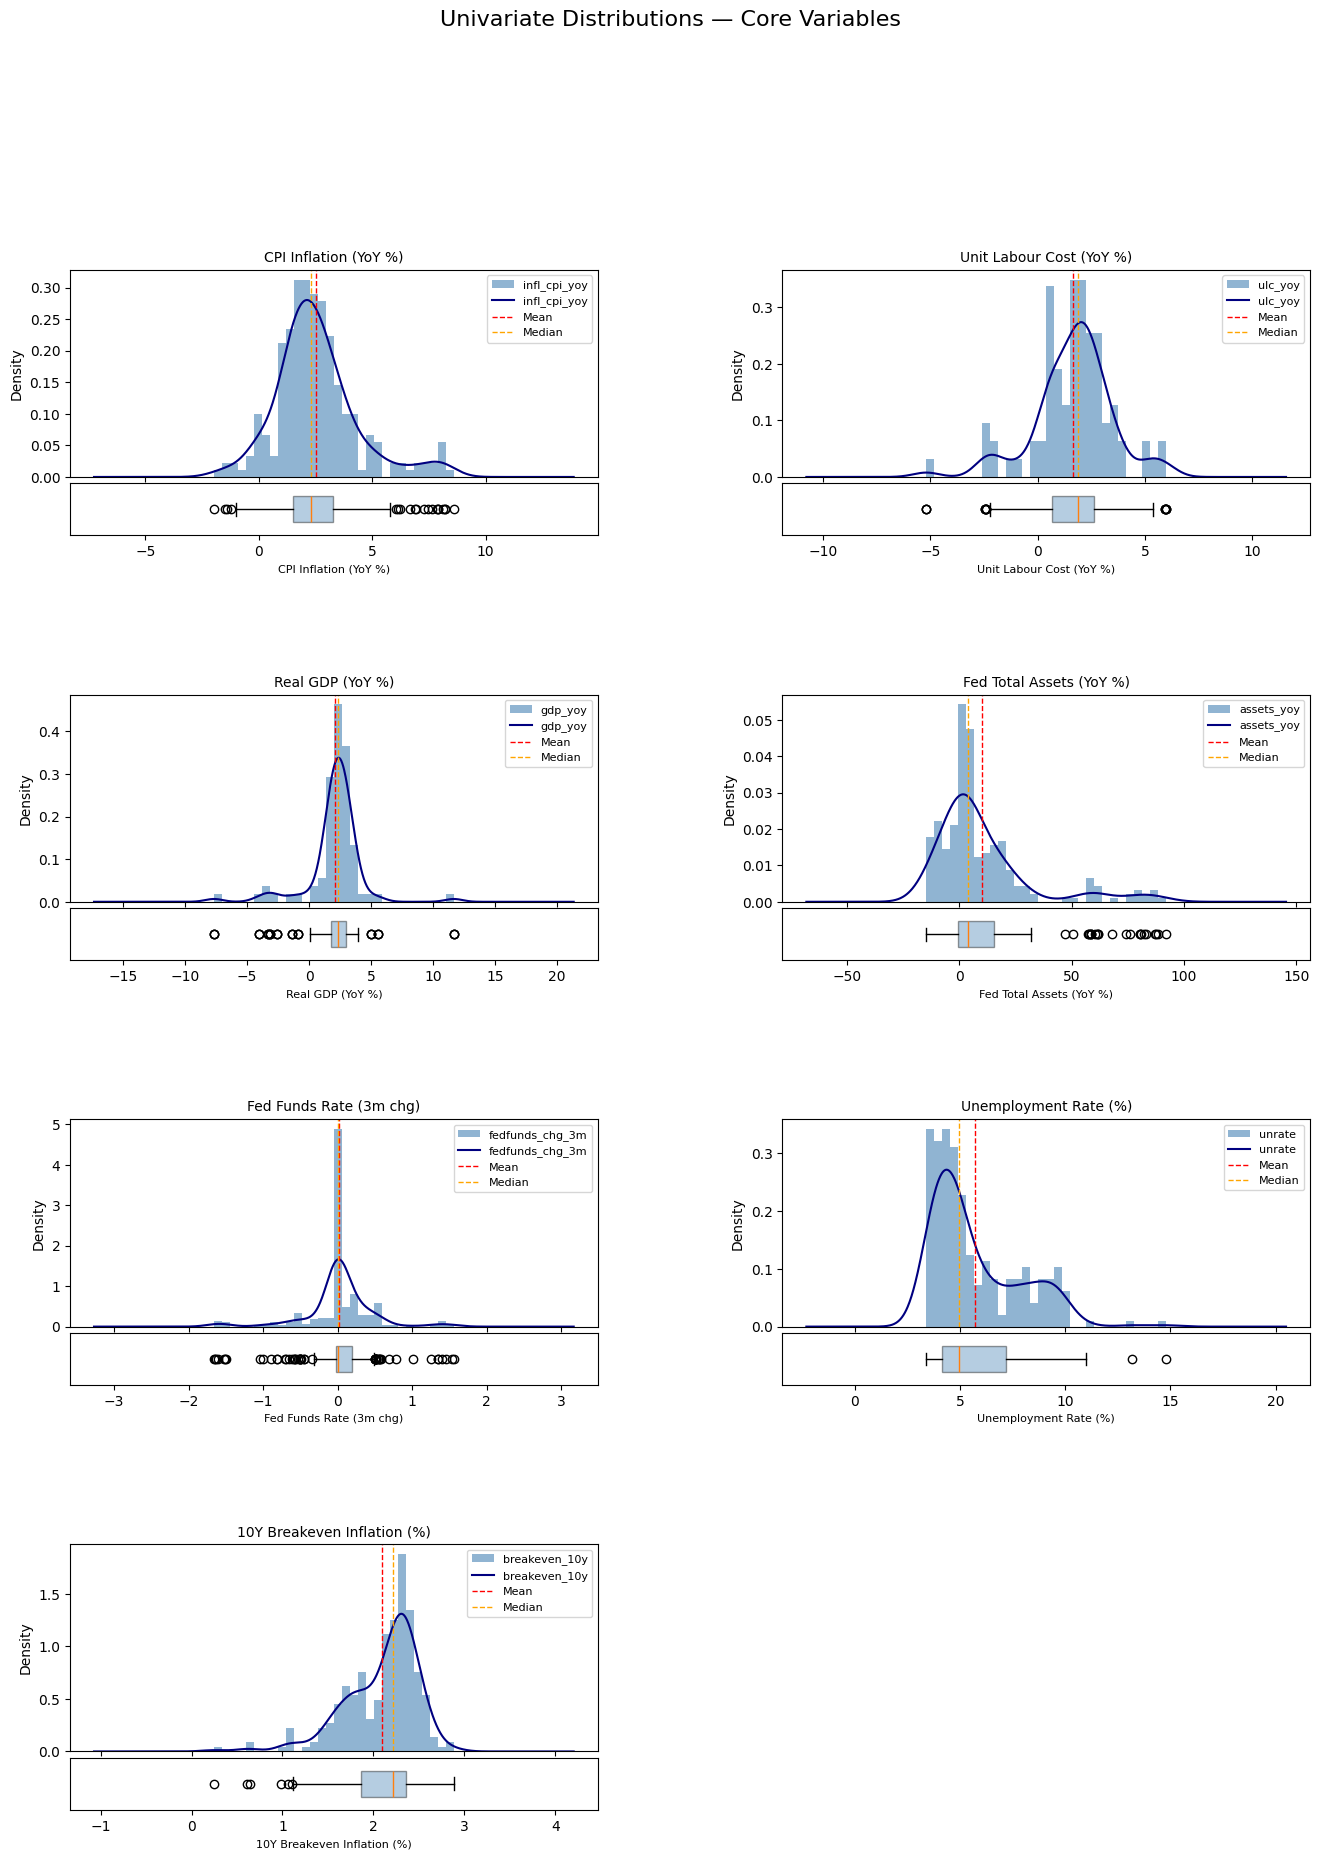

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

LABELS = {
    "infl_cpi_yoy"    : "CPI Inflation (YoY %)",
    "ulc_yoy"         : "Unit Labour Cost (YoY %)",
    "gdp_yoy"         : "Real GDP (YoY %)",
    "assets_yoy"      : "Fed Total Assets (YoY %)",
    "fedfunds_chg_3m" : "Fed Funds Rate (3m chg)",
    "unrate"          : "Unemployment Rate (%)",
    "breakeven_10y"   : "10Y Breakeven Inflation (%)",
}

# Plot: histogram + KDE + boxplot per variable
fig = plt.figure(figsize=(16, 20))
fig.suptitle("Univariate Distributions — Core Variables", fontsize=16, y=1.01)

for i, var in enumerate(CORE_VARS):
    # Each variable gets two subplots: histogram+KDE (top) and boxplot (bottom)
    gs = gridspec.GridSpecFromSubplotSpec(
        2, 1,
        subplot_spec=gridspec.GridSpec(4, 2, figure=fig, hspace=0.6, wspace=0.35)[i],
        height_ratios=[4, 1], hspace=0.05
    )
    ax_hist = fig.add_subplot(gs[0])
    ax_box  = fig.add_subplot(gs[1], sharex=ax_hist)

    # Histogram + KDE
    ml_df[var].plot.hist(ax=ax_hist, bins=30, color="steelblue", alpha=0.6, density=True)
    ml_df[var].plot.kde(ax=ax_hist, color="navy", linewidth=1.5)
    ax_hist.axvline(ml_df[var].mean(),   color="red",    linestyle="--", linewidth=1, label="Mean")
    ax_hist.axvline(ml_df[var].median(), color="orange", linestyle="--", linewidth=1, label="Median")
    ax_hist.set_title(LABELS[var], fontsize=10)
    ax_hist.set_ylabel("Density")
    ax_hist.legend(fontsize=8)
    ax_hist.tick_params(labelbottom=False)

    # Boxplot
    ax_box.boxplot(ml_df[var].dropna(), vert=False, widths=0.5,
                   patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.4))
    ax_box.set_yticks([])
    ax_box.set_xlabel(LABELS[var], fontsize=8)

plt.show()

#### EDA Step 3 — Time Series Plots
The charts below plot the seven core macroeconomic indicators over the full sample period (December 2004 – January 2026). Three major macro events are visible across most series: the 2008–2010 Global Financial Crisis (GFC), the 2020 COVID shock, and the 2021–2023 post-COVID inflation surge.

CPI inflation remained broadly anchored between 1–4% for most of the sample, briefly turning negative during the GFC demand collapse, before surging to a peak of 8.6% in mid-2022 and subsequently returning toward target. Unit labour costs and GDP growth follow a similar cyclical pattern, with sharp negative readings during both the GFC and COVID recessions followed by strong rebounds. The COVID recovery in GDP growth is particularly striking, producing the largest positive and negative values in the dataset.

Federal Reserve total assets growth reflects the three major quantitative easing episodes — post-GFC, COVID-era, and the subsequent balance sheet runoff — with YoY growth reaching above 90% at the peak of COVID-era expansion. The fed funds rate change series captures the two major tightening cycles (2004–2006 and 2022–2023) and the emergency cutting episodes (2008–2009 and 2020), with long flat periods near zero in between. Unemployment displays the characteristic asymmetric spike pattern of recessions — rising sharply and recovering slowly — with the COVID shock being a notable exception due to its brevity. The 10-year breakeven inflation rate is the most stable series overall, trading in a narrow band around 2%, with downward shifts only during the acute phases of the GFC and COVID crises.

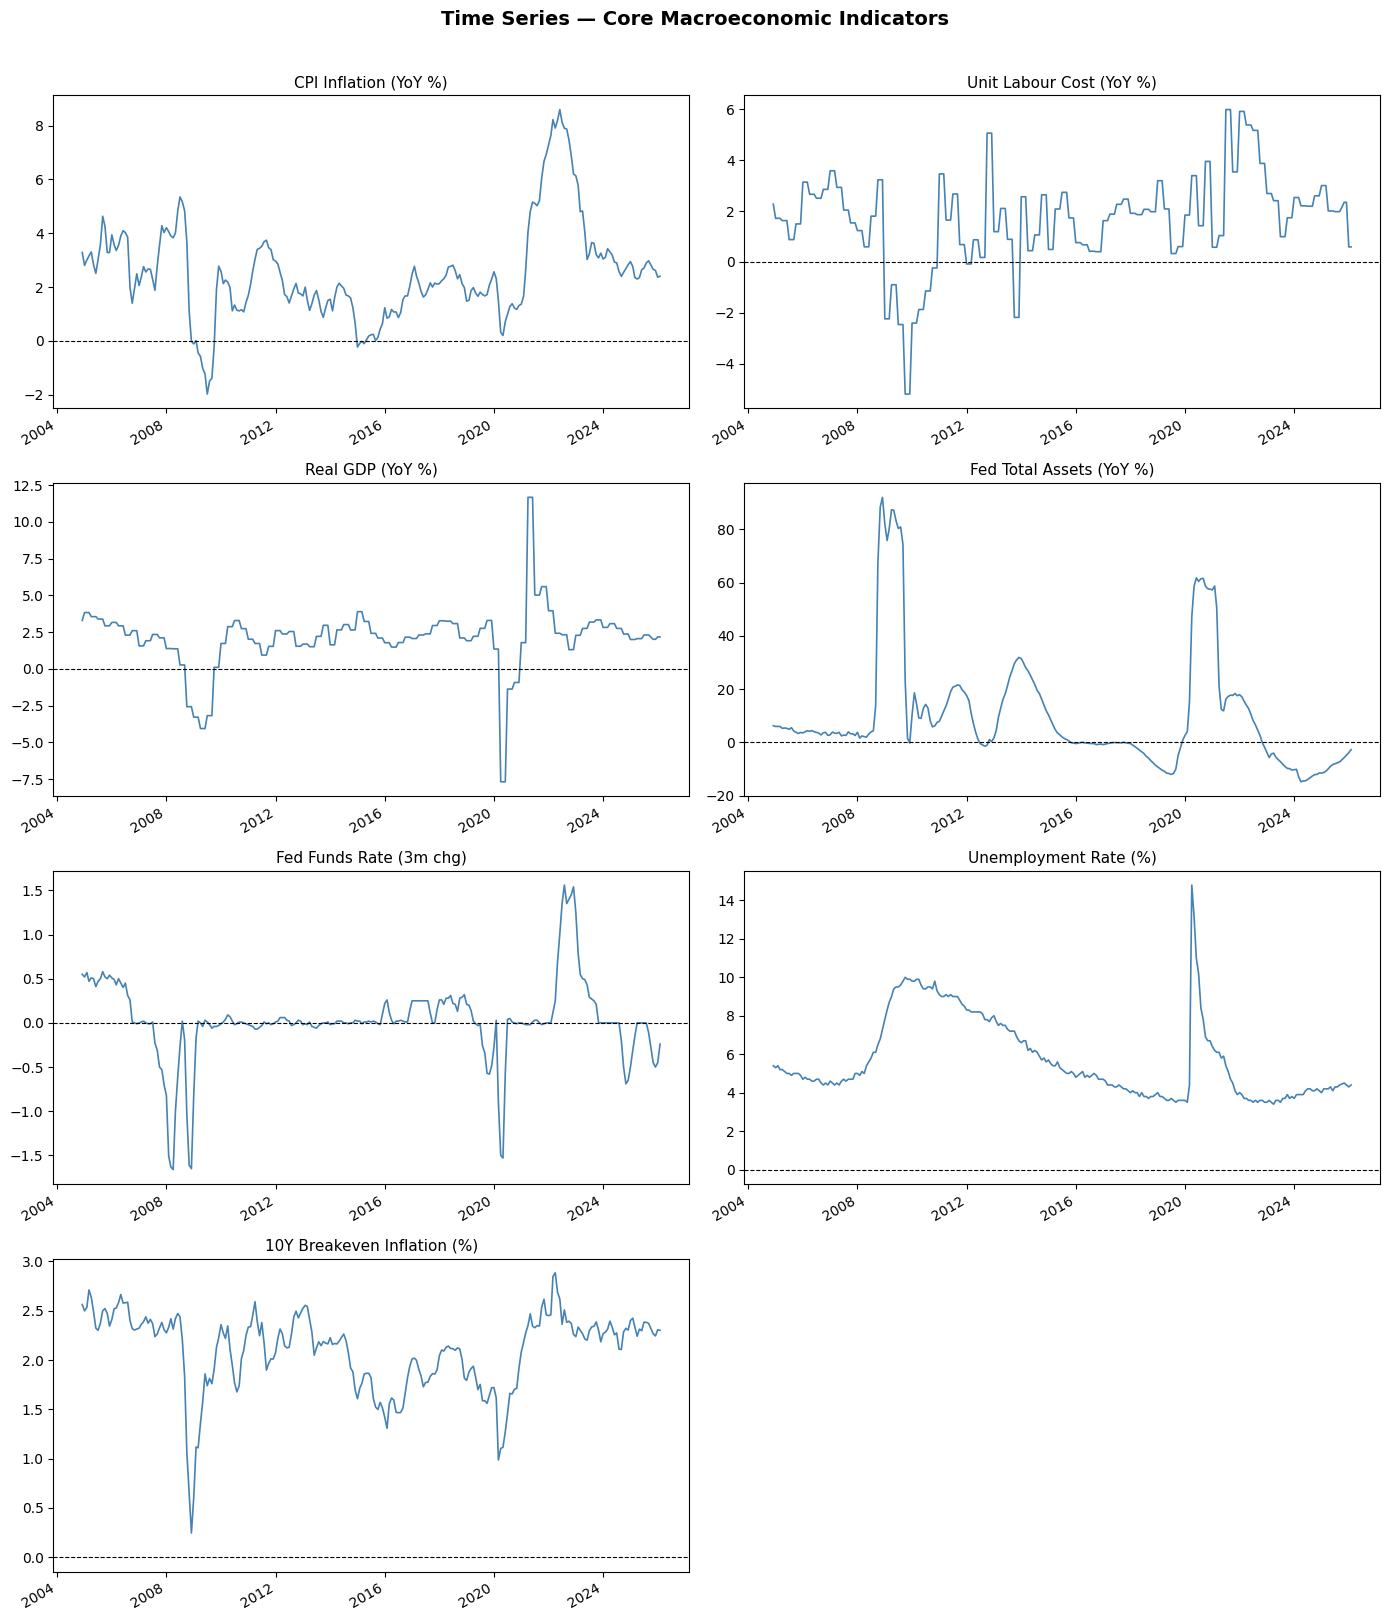

In [ ]:
# Plot time series
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(CORE_VARS):
    ax = axes[i]
    ml_df[col].plot(ax=ax, color="steelblue", linewidth=1.2)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(LABELS[col], fontsize=11)
    ax.set_xlabel("")

axes[-1].set_visible(False)  # hide empty 8th cell

fig.suptitle("Time Series — Core Macroeconomic Indicators", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


#### EDA Step 4 — Correlation Analysis
This step examines linear (Pearson) correlations across the core variables and their lags at 1, 6, and 12 months. The analysis is split into two parts: correlations between each predictor and the inflation target, and pairwise correlations among predictors to assess multicollinearity.

**Correlation with CPI Inflation**
The bar chart ranks each predictor by its Pearson correlation with infl_cpi_yoy. The 10-year breakeven inflation rate is the strongest positive predictor, both contemporaneously and across all lags, reflecting that market inflation expectations closely track realised CPI. Unit labour costs and unemployment also show meaningful correlations, consistent with tighter labour market feeding into price pressures. Fed funds rate changes correlate positively at shorter lags — rate hikes tend to follow inflation — but the relationship weakens at lag 12, reflecting the delayed nature of monetary policy transmission. GDP and Fed total assets show weaker or mixed correlations with inflation across the lags considered.

**Pairwise Correlations Among Predictors**
The heatmap reveals two key patterns. First, strong within-variable autocorrelation is visible along the lag families (e.g. unrate, unrate_lag1, unrate_lag6), which is expected given the persistence of macroeconomic series. Second, meaningful cross-variable correlations exist between unemployment and GDP and between breakeven inflation and ULC. This degree of multicollinearity has practical implications for modelling: feature selection methods such as LASSO or dimensionality reduction via PCA are advisable before fitting ML models to avoid inflated coefficient variance.

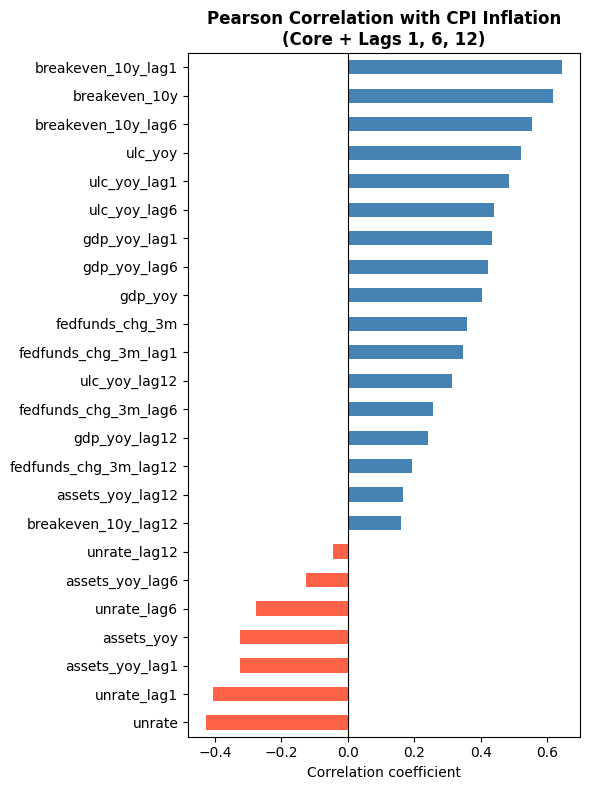

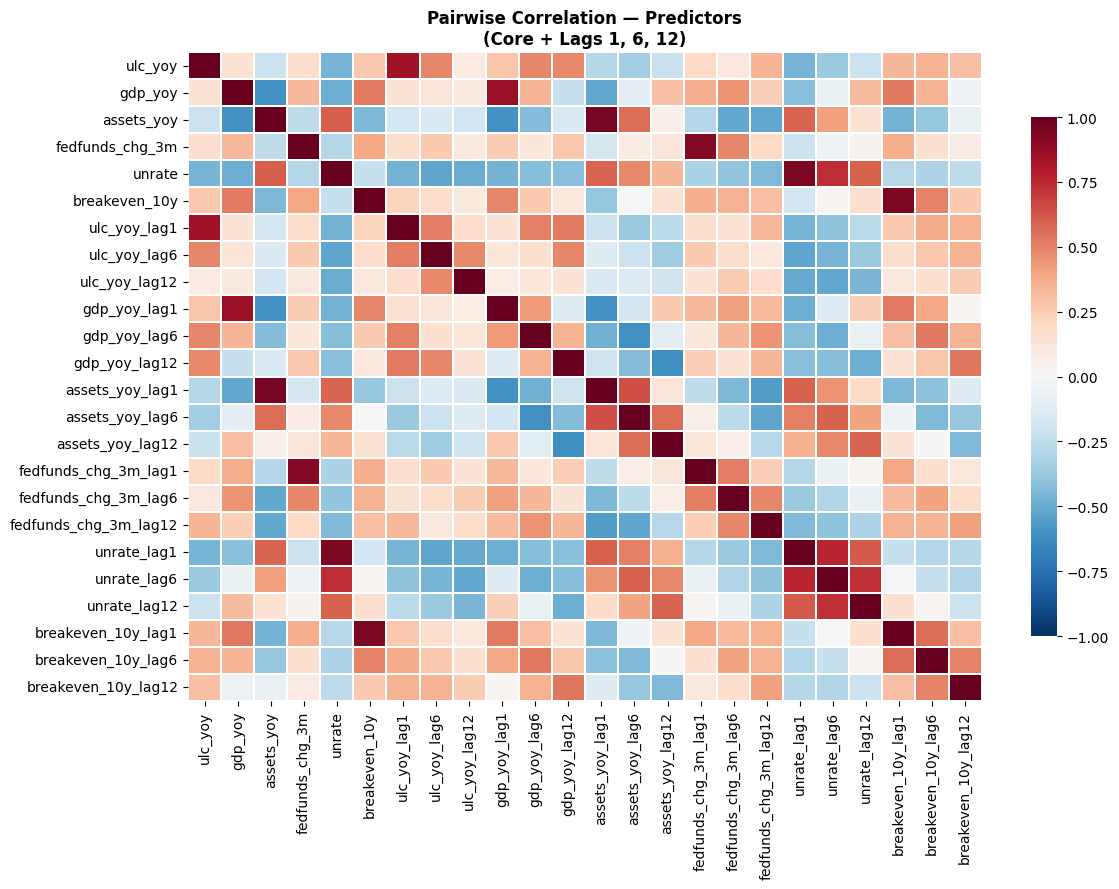

In [ ]:
import seaborn as sns

LAGS = [1, 6, 12]
LAG_COLS = [f"{v}_lag{l}" for v in CORE_VARS[1:] for l in LAGS]  # exclude inflation lags as predictors
PREDICTORS = CORE_VARS[1:] + LAG_COLS

# Step 1: Correlation with inflation (bar chart)
corr_infl = ml_df[["infl_cpi_yoy"] + PREDICTORS].corr(method="pearson")["infl_cpi_yoy"].drop("infl_cpi_yoy")
corr_infl = corr_infl.sort_values()

fig, ax = plt.subplots(figsize=(6, 8))
colors = ["steelblue" if v >= 0 else "tomato" for v in corr_infl]
corr_infl.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson Correlation with CPI Inflation\n(Core + Lags 1, 6, 12)", fontsize=12, fontweight="bold")
ax.set_xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

#  Step 2: Pairwise heatmap among predictors
corr_matrix = ml_df[PREDICTORS].corr(method="pearson")

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.3, annot=False, cbar_kws={"shrink": 0.8})
ax.set_title("Pairwise Correlation — Predictors\n(Core + Lags 1, 6, 12)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


___ ___

# Quantifying Key Drivers of Inflation Using Supervised Machine Learning Models

## Model Design
Three linear regression models were selected to estimate the key drivers of CPI inflation: LASSO, Ridge, and Bayesian Ridge.

**Feature Selection**  
Features were selected based on economic theory and the correlation analysis conducted in the EDA. The core predictors span three macro domains: labour market tightness (ulc_yoy, unrate), monetary policy and financial conditions (fedfunds_chg_3m, assets_yoy, breakeven_10y), and real activity (gdp_yoy). Lagged versions at 3, 6, and 12 months were included to capture delayed transmission effects — for instance, monetary policy typically affects inflation with a lag of several quarters. The own lag of inflation (infl_cpi_yoy_lag1) was retained to account for inflation persistence, a well-documented feature of CPI dynamics. Three binary crisis dummies were added to handle regime shifts: the Global Financial Crisis (Sep 2008 – Mar 2010), the COVID shock (Mar 2020 – Jun 2021), and the post-COVID inflation surge (Jul 2021 – Jun 2023).

**Hyperparameter Tuning**  
LASSO and Ridge were tuned using GridSearchCV over 50 logarithmically spaced values of the regularisation parameter α ∈ [0.0001, 100], with TimeSeriesSplit (5 folds) as the cross-validation strategy. Standard k-fold cross-validation was deliberately avoided, as random shuffling of time series data introduces look-ahead bias. The optimal α was selected by minimising RMSE across the expanding validation windows. Bayesian Ridge does not require manual hyperparameter tuning — it estimates the regularisation parameters α (noise precision) and λ (weight precision) automatically via evidence maximisation, making it self-calibrating and well-suited to small samples.

**Why These Three Models**  
LASSO was chosen for its built-in feature selection — by shrinking irrelevant coefficients to exactly zero, it identifies the most parsimonious set of inflation drivers, which is directly relevant to the interpretive goal of this analysis. Ridge was included as a complement: rather than eliminating features, it shrinks all coefficients proportionally, which is preferable when multiple correlated predictors each carry partial signal — as is the case with the lag structure here. Bayesian Ridge extends Ridge regression into a probabilistic framework, producing posterior distributions over coefficients rather than point estimates. This adds two capabilities absent from the other models: prediction intervals on the test set, and uncertainty quantification per coefficient — allowing a distinction between features that are robustly significant and those whose effect is statistically uncertain given the sample size.

In [ ]:
# Import sklearn packages
from sklearn.linear_model import LinearRegression, Lasso, Ridge, BayesianRidge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
# Add crisis dummy variable to flag unsual periods of peak inflation
ml_df["dummy_gfc"]   = ((ml_df.index >= "2008-09") & (ml_df.index <= "2010-03")).astype(int)
ml_df["dummy_covid"] = ((ml_df.index >= "2020-03") & (ml_df.index <= "2021-06")).astype(int)
ml_df["dummy_surge"] = ((ml_df.index >= "2021-07") & (ml_df.index <= "2023-06")).astype(int)

In [ ]:
# Select the features and the target
FEATURES = [
    "ulc_yoy", "gdp_yoy", "assets_yoy", "fedfunds_chg_3m", "unrate", "breakeven_10y",
    "infl_cpi_yoy_lag1",
    "fedfunds_chg_3m_lag3", "unrate_lag3",
    "ulc_yoy_lag6", "gdp_yoy_lag6", "assets_yoy_lag6",
    "fedfunds_chg_3m_lag6", "unrate_lag6", "breakeven_10y_lag6",
    "ulc_yoy_lag12", "gdp_yoy_lag12", "assets_yoy_lag12",
    "fedfunds_chg_3m_lag12", "unrate_lag12", "breakeven_10y_lag12",
    "dummy_gfc", "dummy_covid", "dummy_surge",
]
TARGET = "infl_cpi_yoy"

data = ml_df[FEATURES + [TARGET]].dropna()

X, y = data[FEATURES], data[TARGET]

In [ ]:
# Tain test split with test size at 0.2 and no shuffle
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, shuffle=False  # shuffle=False preserves temporal order
)

print(f"Train: {X_train.index[0].date()} → {X_train.index[-1].date()}  ({len(X_train)} obs)")
print(f"Test : {X_test.index[0].date()}  → {X_test.index[-1].date()}  ({len(X_test)} obs)\n")

Train: 2004-12-01 → 2021-10-01  (203 obs)
Test : 2021-11-01  → 2026-02-01  (51 obs)



In [ ]:
# ── Grid search with TimeSeriesSplit ──────────────────────────────────────────
tscv   = TimeSeriesSplit(n_splits=5)
alphas = np.logspace(-4, 2, 50)

models = {
    "LASSO": {"pipeline": Pipeline([("scaler", StandardScaler()), ("model", Lasso(max_iter=10000))]),
               "grid": {"model__alpha": alphas}},
    "Ridge": {"pipeline": Pipeline([("scaler", StandardScaler()), ("model", Ridge())]),
               "grid": {"model__alpha": alphas}},
}

results = []
best_params = {}
best_models = {}

for name, config in models.items():
    gs = GridSearchCV(
        config["pipeline"], config["grid"], cv=tscv,
        scoring="neg_root_mean_squared_error", n_jobs=-1
    )
    gs.fit(X_train, y_train)
    best_params[name] = gs.best_params_
    best_models[name] = gs.best_estimator_

    y_pred = gs.best_estimator_.predict(X_test)
    results.append({
        "Model":      name,
        "Best alpha": best_params[name].get("model__alpha", "N/A"),
        "RMSE":       round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        "MAE":        round(mean_absolute_error(y_test, y_pred), 4),
        "R²":         round(r2_score(y_test, y_pred), 4),
    })

# ── BayesianRidge — fit separately (self-tuning, no grid search needed) ───────
bayes_pipeline = Pipeline([("scaler", StandardScaler()), ("model", BayesianRidge(max_iter=300, tol=1e-6))])
bayes_pipeline.fit(X_train, y_train)
best_models["BayesianRidge"] = bayes_pipeline



## Model Evaluation
**Performance Metrics**  
Model performance was evaluated on the held-out test set (October 2021 – January 2026) using RMSE, MAE, and R². RMSE was the primary metric given the extreme inflation values in the test period, as it penalises large errors more heavily.  
BayesianRidge is the strongest performer at R² of 0.96 and RMSE of 0.416. LASSO performs reasonably at R² of 0.896, with the accuracy cost reflecting its aggressive feature selection at the optimal alpha of 0.20. Ridge underperforms despite its theoretical strengths — the cross-validated alpha of 100 imposes shrinkage strong enough to underfit the test set, suggesting its penalty structure is less well-suited to this dataset than LASSO's selective zeroing or BayesianRidge's probabilistic shrinkage. The strong performance of BayesianRidge is partly attributable to the post-COVID surge dummy, which allows it to account for the structural break explicitly rather than extrapolating it from economic features alone.  

**Actual vs Predicted Curves**  
All three models track the observed inflation series closely across the test period, including the rise toward 8.6% in mid-2022 and the subsequent disinflation through 2023–2024. A common pattern emerges: all models tend to underpredict at the peak of the surge and overpredict slightly during disinflation, suggesting the speed of the regime transition is not fully captured by the lagged feature structure.
The BayesianRidge panel is distinctive in showing a 95% credible interval around each prediction. This uncertainty quantification is a key practical advantage over the other models, particularly in contexts where communicating forecast confidence is as important as the point estimate.  

**Model Coefficients and Feature Importance**
Across all three models, infl_cpi_yoy_lag1 carries the largest positive coefficient by a wide margin, confirming that inflation is highly persistent. Beyond the own lag, breakeven_10y is the most important economic driver — its reliably positive coefficient reflects the self-fulfilling role of inflation expectations in wage and pricing decisions. fedfunds_chg_3m_lag3 enters negatively across models, capturing the delayed contractionary effect of monetary tightening consistent with standard transmission mechanisms. breakeven_10y_lag12 is also consistently negative, reflecting the anchoring effect of lower long-run expectations.
In the BayesianRidge plot, the posterior error bars add an important interpretive layer.

In [ ]:
y_pred_bayes = bayes_pipeline.predict(X_test)
results.append({
    "Model":      "BayesianRidge",
    "Best alpha": "self-tuned",
    "RMSE":       round(np.sqrt(mean_squared_error(y_test, y_pred_bayes)), 4),
    "MAE":        round(mean_absolute_error(y_test, y_pred_bayes), 4),
    "R²":         round(r2_score(y_test, y_pred_bayes), 4),
})

results_df = pd.DataFrame(results).set_index("Model")
print("── Model Performance after GridSearchCV + TimeSeriesSplit ────")
print(results_df.to_string())

# Making a copy of linear results so i can compare it to my random forest regression (Feyi)
linear_results = results.copy()

── Model Performance after GridSearchCV + TimeSeriesSplit ────
               Best alpha    RMSE     MAE      R²
Model                                            
LASSO            0.202359  0.6836  0.4824  0.8966
Ridge               100.0  0.9293  0.6659  0.8090
BayesianRidge  self-tuned  0.4138  0.3464  0.9621


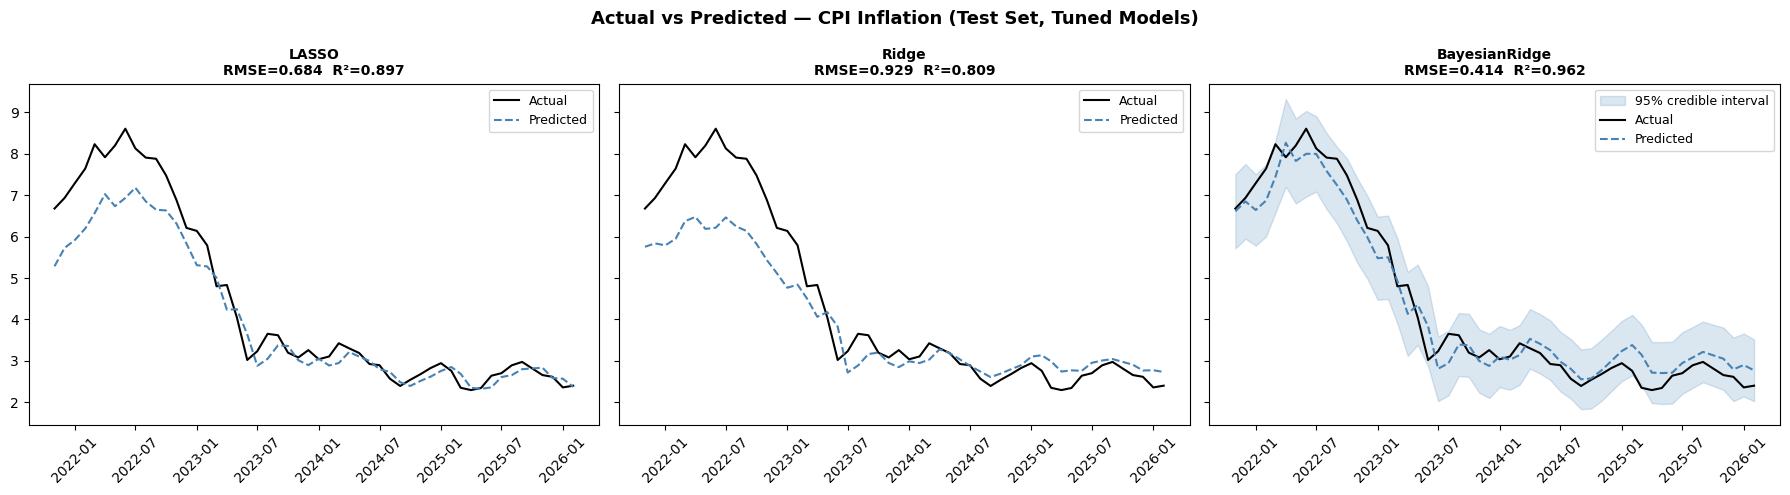

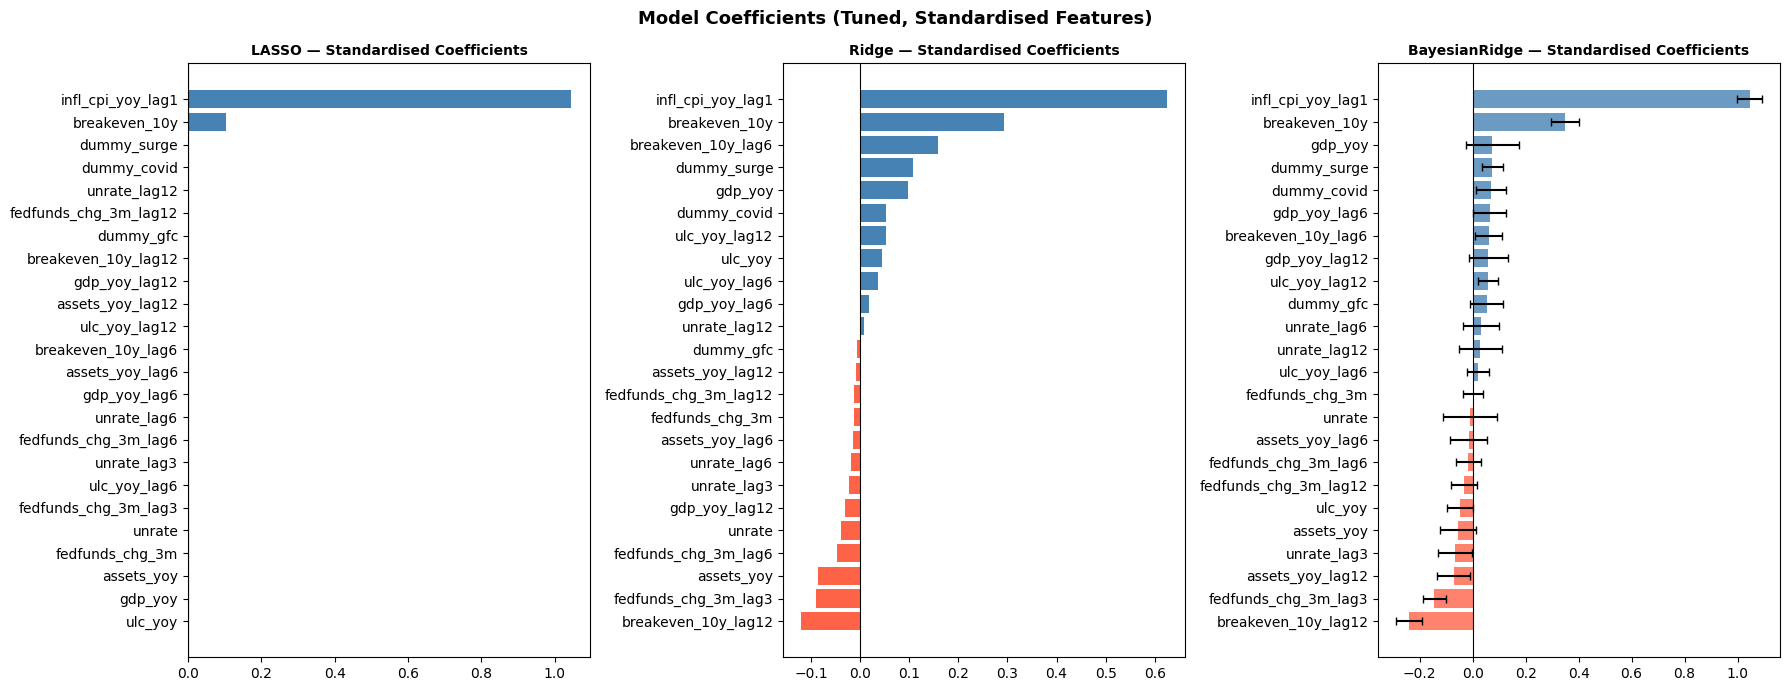

In [ ]:
# Plot the actual vs prediciton curve and the coefficients
## 1. Actual vs Predicted
PLOT_MODELS = ["LASSO", "Ridge", "BayesianRidge"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, name in zip(axes, PLOT_MODELS):
    if name == "BayesianRidge":
        # scale X_test manually to call predict with return_std
        scaler  = best_models[name].named_steps["scaler"]
        br      = best_models[name].named_steps["model"]
        y_pred, y_std = br.predict(scaler.transform(X_test), return_std=True)
        ax.fill_between(y_test.index, y_pred - 1.96 * y_std, y_pred + 1.96 * y_std,
                        color="steelblue", alpha=0.2, label="95% credible interval")
    else:
        y_pred = best_models[name].predict(X_test)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    ax.plot(y_test.index, y_test.values, label="Actual",    color="black",     linewidth=1.5)
    ax.plot(y_test.index, y_pred,        label="Predicted", color="steelblue", linewidth=1.5, linestyle="--")
    ax.set_title(f"{name}\nRMSE={rmse:.3f}  R²={r2:.3f}", fontsize=10, fontweight="bold")
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Actual vs Predicted — CPI Inflation (Test Set, Tuned Models)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# 2. Standardised coefficients
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, name in zip(axes, PLOT_MODELS):
    model = best_models[name].named_steps["model"]
    coefs = model.coef_
    order = np.argsort(coefs)
    colors = ["tomato" if c < 0 else "steelblue" for c in coefs[order]]

    if name == "BayesianRidge":
        # add std dev as error bars
        coef_std = np.sqrt(np.diag(model.sigma_))
        ax.barh(np.array(FEATURES)[order], coefs[order], xerr=coef_std[order],
                color=colors, capsize=3, alpha=0.8)
    else:
        ax.barh(np.array(FEATURES)[order], coefs[order], color=colors)

    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{name} — Standardised Coefficients", fontsize=10, fontweight="bold")

plt.suptitle("Model Coefficients (Tuned, Standardised Features)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

___ ___

## Random Forest Regression

To complement the linear models (Lasso, Ridge, and Bayesian Ridge), we implement a **Random Forest Regressor** as a nonlinear machine learning benchmark.

Random Forest is an ensemble method that builds many decision trees on different bootstrap samples of the training data and averages their predictions. This allows it to capture:

- **nonlinear relationships**
- **interactions between macroeconomic variables**
- **complex threshold effects**

Unlike ARIMA and VAR, Random Forest does not model time dynamics directly, so the temporal structure is incorporated through the **lagged features** created earlier in the notebook.

This model helps us test whether inflation is better explained by nonlinear combinations of macroeconomic indicators than by purely linear methods.



In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

### Why no feature scaling?

Unlike Lasso and Ridge, Random Forest does **not require feature scaling** because tree-based models split on thresholds rather than estimating coefficients that depend on feature magnitude.

Therefore, we train the model directly on the original feature values.

In [ ]:
# ── Random Forest: hyperparameter tuning with TimeSeriesSplit ──────────────────
rf = RandomForestRegressor(random_state=42)
ml_results = []
rf_param_dist = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [3, 5, 7, 9, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_dist,
    n_iter=25,
    cv=tscv,   # re-use TimeSeriesSplit from earlier section
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

best_models["RandomForest"] = best_rf
best_params["RandomForest"] = rf_search.best_params_

ml_results.append({
    "Model":      "RandomForest",
    "Best alpha": "N/A",
    "RMSE":       round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 4),
    "MAE":        round(mean_absolute_error(y_test, y_pred_rf), 4),
    "R²":         round(r2_score(y_test, y_pred_rf), 4),
})

results_df = pd.DataFrame(ml_results).set_index("Model")
print("── Model Performance including Random Forest ────")
print(results_df.to_string())

print("\nBest Random Forest Parameters:")
print(rf_search.best_params_)

── Model Performance including Random Forest ────
             Best alpha    RMSE     MAE     R²
Model                                         
RandomForest        N/A  1.6809  1.0677  0.375

Best Random Forest Parameters:
{'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 7}


### Random Forest evaluation

The Random Forest model is evaluated on the same held-out test period as the linear models. This preserves comparability across models.

Because the test set begins during the post-2021 inflation surge, the evaluation is intentionally challenging and should be interpreted as a test of how well the model handles a structural change in the inflation regime.

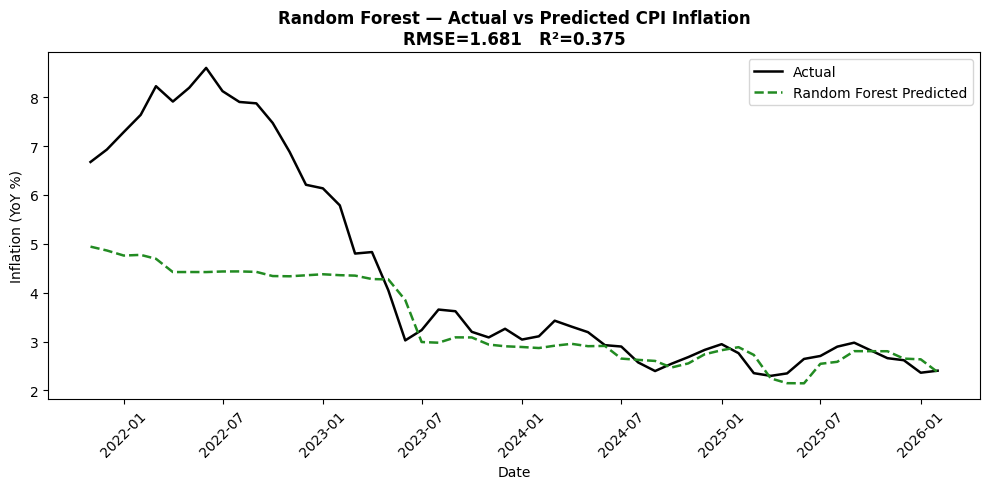

In [ ]:
# ── Actual vs Predicted: Random Forest ─────────────────────────────────────────
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2   = r2_score(y_test, y_pred_rf)

plt.figure(figsize=(10, 5))
plt.plot(y_test.index, y_test.values, label="Actual", linewidth=1.8, color="black")
plt.plot(y_test.index, y_pred_rf, label="Random Forest Predicted", linewidth=1.8, linestyle="--", color="forestgreen")
plt.title(f"Random Forest — Actual vs Predicted CPI Inflation\nRMSE={rf_rmse:.3f}   R²={rf_r2:.3f}",
          fontsize=12, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Inflation (YoY %)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

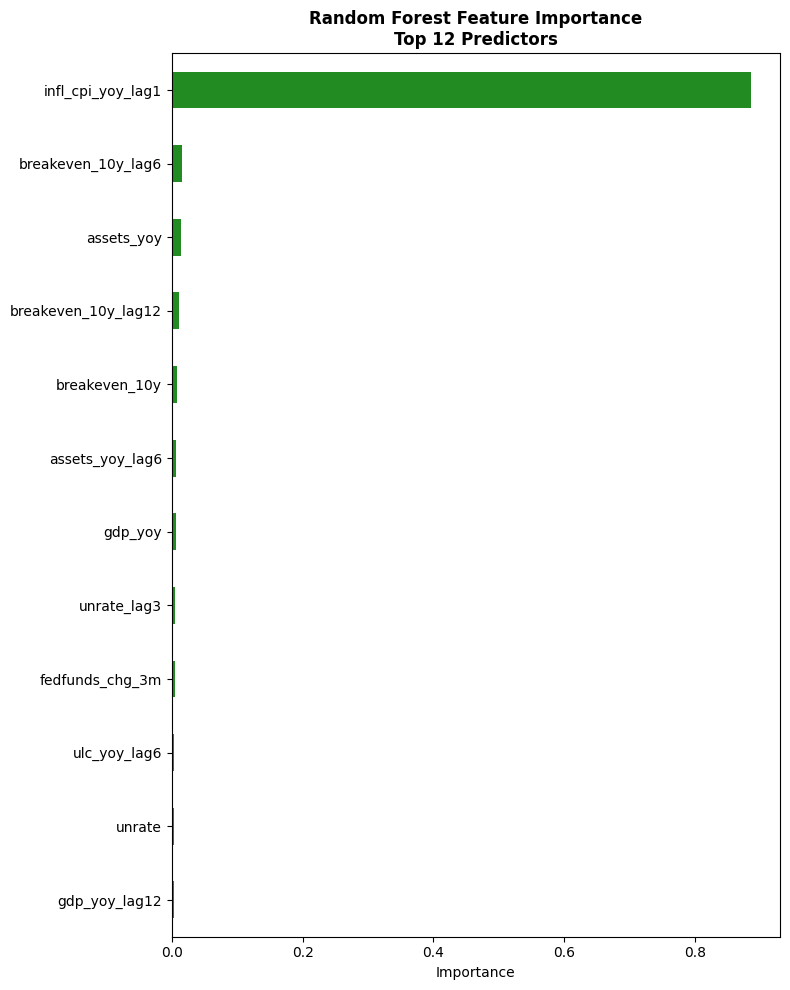

Top 12 most important features:
infl_cpi_yoy_lag1      0.8855
breakeven_10y_lag6     0.0162
assets_yoy             0.0141
breakeven_10y_lag12    0.0107
breakeven_10y          0.0078
assets_yoy_lag6        0.0068
gdp_yoy                0.0060
unrate_lag3            0.0055
fedfunds_chg_3m        0.0049
ulc_yoy_lag6           0.0040
unrate                 0.0039
gdp_yoy_lag12          0.0039


In [ ]:
# ── Feature importance ─────────────────────────────────────────────────────────
rf_importance = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 10))
rf_importance.tail(12).plot(kind="barh", color="forestgreen")
plt.title("Random Forest Feature Importance\nTop 12 Predictors", fontsize=12, fontweight="bold")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 12 most important features:")
print(rf_importance.sort_values(ascending=False).head(12).round(4).to_string())

### Interpreting feature importance

Feature importance in Random Forest shows which predictors contributed most to reducing prediction error across the ensemble of trees.

This does **not** imply causality, but it does indicate which variables the model relied on most heavily. In inflation forecasting, we expect lagged inflation to rank highly because inflation is often persistent over time.

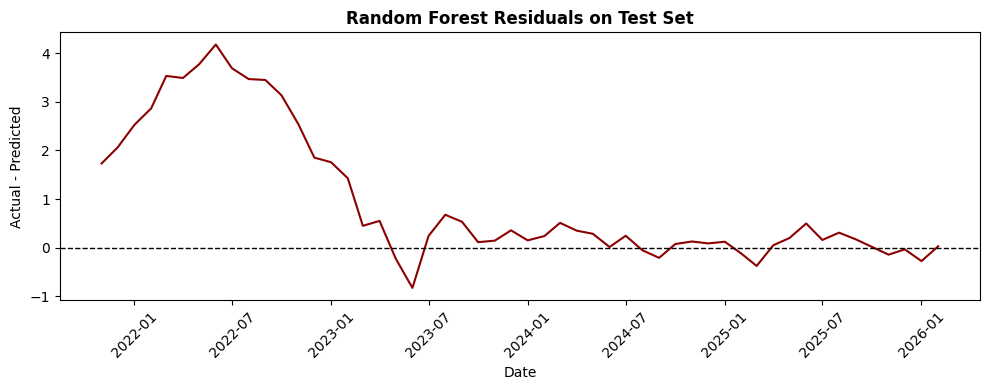

In [ ]:
# ── Residual analysis ──────────────────────────────────────────────────────────
rf_residuals = y_test - y_pred_rf

plt.figure(figsize=(10, 4))
plt.plot(y_test.index, rf_residuals, color="darkred", linewidth=1.5)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Random Forest Residuals on Test Set", fontsize=12, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Actual - Predicted")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Gradient Boosting Regression

As an additional nonlinear benchmark, we implement a **Gradient Boosting Regressor**.

Unlike Random Forest, which averages many independent trees, Gradient Boosting builds trees sequentially. Each new tree is trained to correct the residual errors made by the previous trees. This often leads to stronger predictive performance, especially when the data contains structured nonlinearities.

We use the same training and test split as the other machine learning models to maintain comparability.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
# ── Gradient Boosting: hyperparameter tuning with TimeSeriesSplit ──────────────
gbr = GradientBoostingRegressor(random_state=42)

gbr_param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.7, 0.85, 1.0]
}

gbr_search = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=gbr_param_dist,
    n_iter=25,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

gbr_search.fit(X_train, y_train)

best_gbr = gbr_search.best_estimator_
y_pred_gbr = best_gbr.predict(X_test)

# Store results in your ML results list
ml_results.append({
    "Model": "GradientBoosting",
    "Best alpha": "N/A",
    "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred_gbr)), 4),
    "MAE": round(mean_absolute_error(y_test, y_pred_gbr), 4),
    "R²": round(r2_score(y_test, y_pred_gbr), 4),
})

print("Best Gradient Boosting Parameters:")
print(gbr_search.best_params_)

print("\nGradient Boosting Metrics:")
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_gbr)), 4))
print("MAE :", round(mean_absolute_error(y_test, y_pred_gbr), 4))
print("R²  :", round(r2_score(y_test, y_pred_gbr), 4))

Best Gradient Boosting Parameters:
{'subsample': 0.7, 'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 3, 'learning_rate': 0.03}

Gradient Boosting Metrics:
RMSE: 1.6251
MAE : 1.0092
R²  : 0.4159


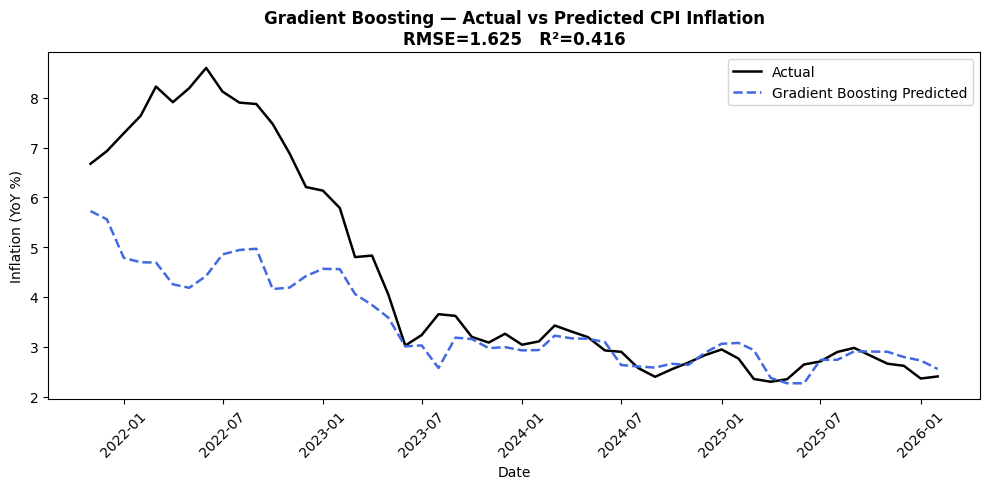

In [ ]:
gbr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
gbr_r2 = r2_score(y_test, y_pred_gbr)

plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test.values, label="Actual", linewidth=1.8, color="black")
plt.plot(y_test.index, y_pred_gbr, label="Gradient Boosting Predicted", linewidth=1.8, linestyle="--", color="royalblue")
plt.title(f"Gradient Boosting — Actual vs Predicted CPI Inflation\nRMSE={gbr_rmse:.3f}   R²={gbr_r2:.3f}",
          fontsize=12, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Inflation (YoY %)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

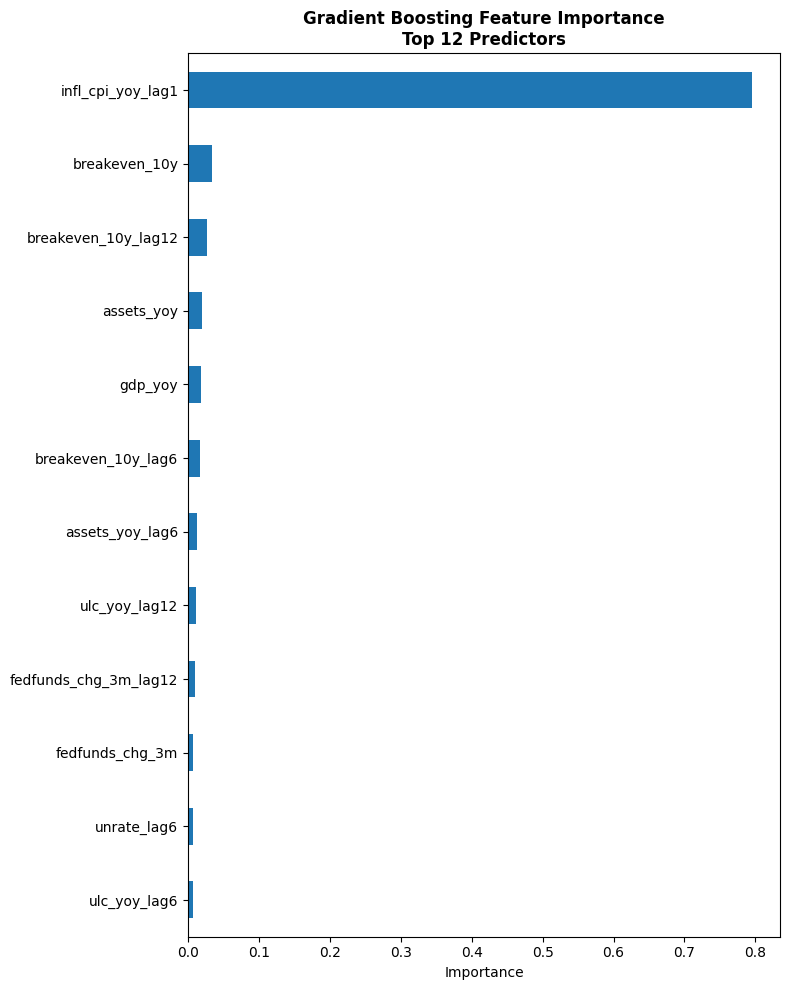

Top 12 Gradient Boosting Features:
infl_cpi_yoy_lag1        0.7951
breakeven_10y            0.0343
breakeven_10y_lag12      0.0264
assets_yoy               0.0195
gdp_yoy                  0.0187
breakeven_10y_lag6       0.0163
assets_yoy_lag6          0.0123
ulc_yoy_lag12            0.0105
fedfunds_chg_3m_lag12    0.0104
fedfunds_chg_3m          0.0064
unrate_lag6              0.0064
ulc_yoy_lag6             0.0062


In [ ]:
gbr_importance = pd.Series(best_gbr.feature_importances_, index=X_train.columns).sort_values(ascending=True)

plt.figure(figsize=(8,10))
gbr_importance.tail(12).plot(kind="barh")
plt.title("Gradient Boosting Feature Importance\nTop 12 Predictors", fontsize=12, fontweight="bold")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 12 Gradient Boosting Features:")
print(gbr_importance.sort_values(ascending=False).head(12).round(4).to_string())

In [ ]:
combined_results = []

# Use saved linear results
if "linear_results" in globals():
    combined_results.extend(linear_results)

# Add Random Forest results
if "ml_results" in globals():
    combined_results.extend(ml_results)

results_df = pd.DataFrame(combined_results).set_index("Model")
print(results_df)

                  Best alpha    RMSE     MAE      R²
Model                                               
LASSO               0.202359  0.6836  0.4824  0.8966
Ridge                  100.0  0.9293  0.6659  0.8090
BayesianRidge     self-tuned  0.4138  0.3464  0.9621
RandomForest             N/A  1.6809  1.0677  0.3750
GradientBoosting         N/A  1.6251  1.0092  0.4159


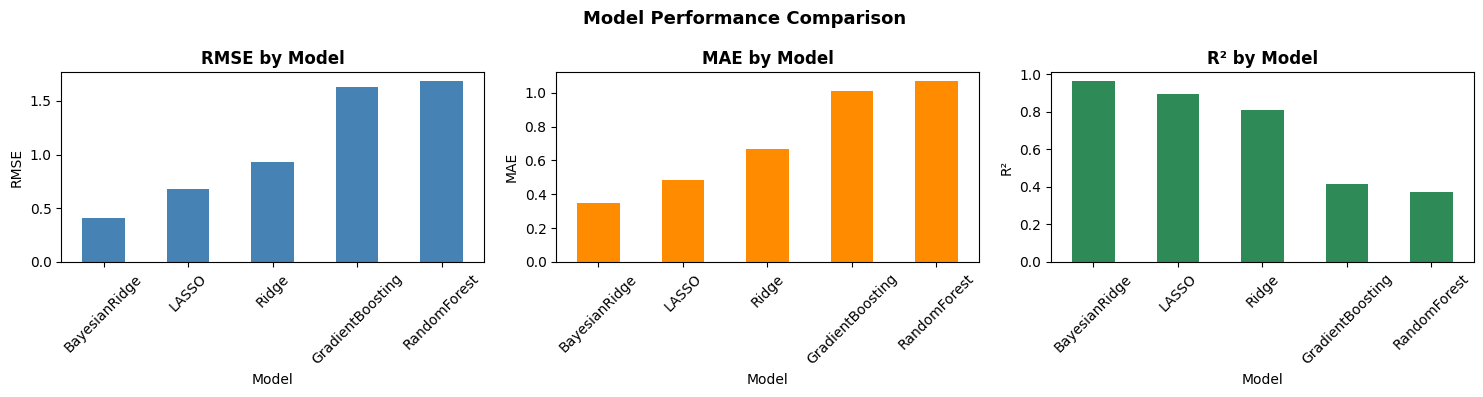

In [ ]:
# ── Model comparison bar chart ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

results_df["RMSE"].sort_values().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("RMSE by Model", fontweight="bold")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=45)

results_df["MAE"].sort_values().plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("MAE by Model", fontweight="bold")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=45)

results_df["R²"].sort_values(ascending=False).plot(kind="bar", ax=axes[2], color="seagreen")
axes[2].set_title("R² by Model", fontweight="bold")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=45)

plt.suptitle("Model Performance Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

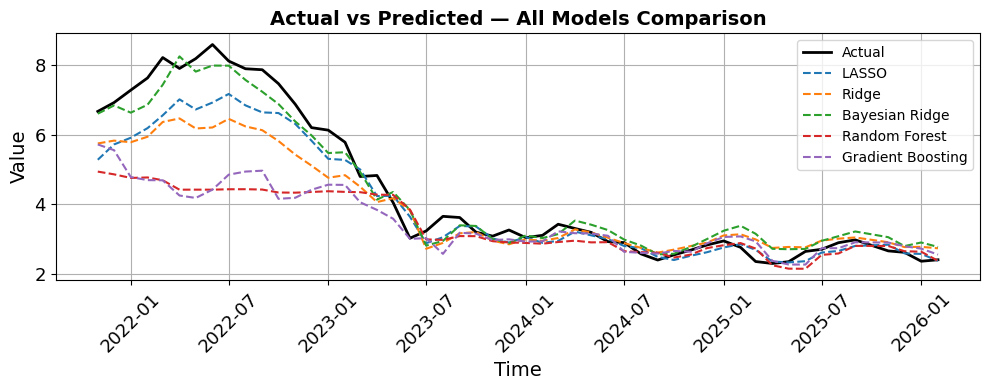

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

plt.figure(figsize=(10, 4))

# --- 1. Plot Actual ---
plt.plot(y_test.index, y_test.values,
         label="Actual", color="black", linewidth=2)

# --- 2. LASSO ---
y_pred_lasso = best_models["LASSO"].predict(X_test)
plt.plot(y_test.index, y_pred_lasso,
         label="LASSO", linestyle="--")

# --- 3. Ridge ---
y_pred_ridge = best_models["Ridge"].predict(X_test)
plt.plot(y_test.index, y_pred_ridge,
         label="Ridge", linestyle="--")

# --- 4. Bayesian Ridge (with optional confidence interval) ---
scaler = best_models["BayesianRidge"].named_steps["scaler"]
br_model = best_models["BayesianRidge"].named_steps["model"]

X_test_scaled = scaler.transform(X_test)
y_pred_bayes, y_std = br_model.predict(X_test_scaled, return_std=True)

plt.plot(y_test.index, y_pred_bayes,
         label="Bayesian Ridge", linestyle="--")

# --- 5. Random Forest ---
plt.plot(y_test.index, y_pred_rf,
         label="Random Forest", linestyle="--")

# --- 6. Gradient Boosting ---
plt.plot(y_test.index, y_pred_gbr,
         label="Gradient Boosting", linestyle="--")

# --- Formatting ---
plt.title("Actual vs Predicted — All Models Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Time", fontsize=14)
plt.ylabel("Value", fontsize=14)
plt.tick_params(axis='both', labelsize=13)
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

___ ___

# Conclusions

This project examined the drivers and predictability of U.S. CPI inflation using both machine learning and econometric methods across a 253-month sample spanning three distinct macroeconomic regimes.  

Among the supervised learning models, linear methods consistently outperformed nonlinear ones. Bayesian Ridge regression achieved the best overall results, with Random Forest and Gradient Boosting both struggling to extrapolate through the post-2021 inflation surge — a known limitation of tree-based models.

Across all approaches, the results point to the same conclusion: U.S. inflation is a persistent, largely linear phenomenon best captured by models that respect its temporal structure and account for structural breaks.
